In [1]:
import numpy as np

def readucr(filename):
    data = np.loadtxt(filename, delimiter="\t")
    y = data[:, 0]
    x = data[:, 1:]
    return x, y.astype(int)

root_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/"

x_train, y_train = readucr(root_url + "FordA_TRAIN.tsv")
x_test, y_test = readucr(root_url + "FordA_TEST.tsv")

print(f" {x_train.shape}")

 (3601, 500)


In [2]:
import pandas as pd
url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TRAIN.tsv"
df = pd.read_csv(url, sep='\t', header=None)

print("عرض أسطر من البيانات:")
display(df.head(2000))

عرض أسطر من البيانات:


,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,-1,-0.797172,-0.664392,-0.373015,0.040815,0.526936,0.984288,1.353120,1.578108,1.659251,...,1.120756,0.722417,0.362068,0.092083,-0.081268,-0.212573,-0.391456,-0.664392,-1.073796,-1.564343
1,1,0.804855,0.634629,0.373474,0.038343,-0.340988,-0.740860,-1.109667,-1.395357,-1.570192,...,0.386403,0.049213,-0.258138,-0.510583,-0.683647,-0.773817,-0.785255,-0.714885,-0.560443,-0.319086
2,-1,0.727985,0.111284,-0.499124,-1.068629,-1.578351,-1.990534,-2.302031,-2.503403,-2.585211,...,0.394463,0.463685,0.507735,0.517174,0.504588,0.476270,0.438513,0.394463,0.339400,0.255391
3,-1,-0.234439,-0.502157,-0.732488,-0.946128,-1.139739,-1.323336,-1.490243,-1.607077,-1.620430,...,-0.952804,-0.929437,-0.922761,-0.929437,-0.909409,-0.835970,-0.695768,-0.478790,-0.188707,0.119736
4,-1,-0.171328,-0.062285,0.235829,0.710396,1.239969,1.649823,1.876321,1.865535,1.703751,...,0.776188,0.725496,0.697453,0.731967,0.808545,0.839823,0.733046,0.437520,-0.026585,-0.602213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,-1,-0.050837,-0.379376,-0.657085,-0.874204,-1.023998,-1.123301,-1.170427,-1.158645,-1.072808,...,1.095010,1.359254,1.532612,1.593204,1.542711,1.392916,1.169066,0.881257,0.563154,0.221487
1996,-1,0.554742,0.655123,0.752790,0.847744,0.920995,0.969828,0.964402,0.904717,0.774494,...,1.414756,1.656212,1.832555,1.943787,1.965491,1.878676,1.661638,1.322515,0.869448,0.348556
1997,-1,-1.540809,-1.531969,-1.364001,-1.036907,-0.583101,-0.073600,0.433543,0.884403,1.232125,...,1.850951,1.998291,1.921674,1.638782,1.199710,0.660446,0.086116,-0.441655,-0.880727,-1.201928
1998,1,2.577909,2.270847,1.851404,1.373658,0.886936,0.432418,0.045211,-0.274386,-0.543576,...,0.087051,0.054018,0.025923,-0.009096,-0.071190,-0.181147,-0.348154,-0.562407,-0.779406,-0.939261


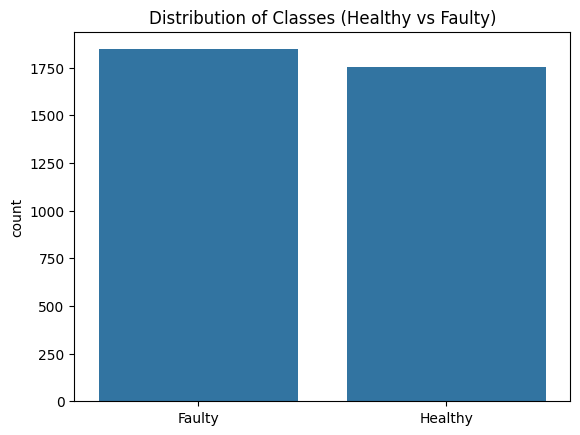

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train)
plt.title('Distribution of Classes (Healthy vs Faulty)')
plt.xticks([0, 1], ['Faulty', 'Healthy'])
plt.show()

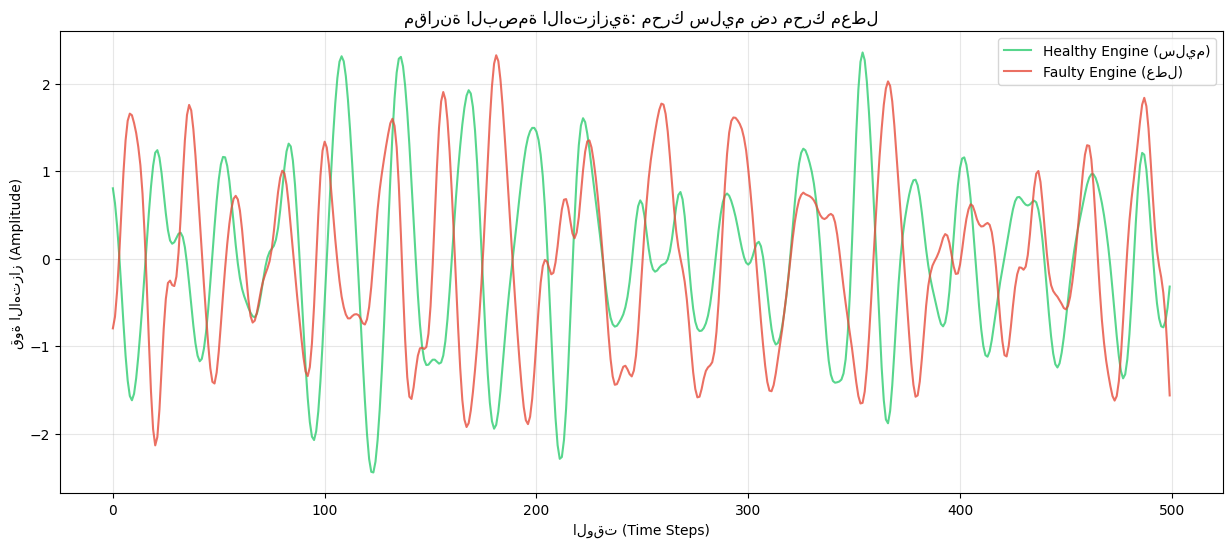

In [4]:
import matplotlib.pyplot as plt

healthy_sample = df[df[0] == 1].iloc[0, 1:]
faulty_sample = df[df[0] == -1].iloc[0, 1:]

plt.figure(figsize=(15, 6))

plt.plot(healthy_sample.values, label='Healthy Engine (سليم)', color='#2ecc71', alpha=0.8)

plt.plot(faulty_sample.values, label='Faulty Engine (عطل)', color='#e74c3c', alpha=0.8)

plt.title("مقارنة البصمة الاهتزازية: محرك سليم ضد محرك معطل")
plt.xlabel("الوقت (Time Steps)")
plt.ylabel("قوة الاهتزاز (Amplitude)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
import pandas as pd
import numpy as np
import os

def load_ford_a_data():
    base_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/"
    train_file = "FordA_TRAIN.tsv"
    test_file = "FordA_TEST.tsv"

    if not os.path.exists(train_file):
        print("  تحميل ملف التدريب")
        os.system(f"wget {base_url}{train_file}")

    if not os.path.exists(test_file):
        print("  تحميل ملف الاختبار")
        os.system(f"wget {base_url}{test_file}")

    train_df = pd.read_csv(train_file, sep='\t', header=None)
    test_df = pd.read_csv(test_file, sep='\t', header=None)
    print(" تم تحميل الملفات ")
    return train_df, test_df

train_df, test_df = load_ford_a_data()

X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

y_train = np.where(y_train == -1, 0, 1)
y_test = np.where(y_test == -1, 0, 1)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).reshape(-1, 500, 1)
X_test_scaled = scaler.transform(X_test).reshape(-1, 500, 1)

print("***")

 تم تحميل الملفات 
***


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

train_df = pd.read_csv('FordA_TRAIN.tsv', sep='\t', header=None)
test_df = pd.read_csv('FordA_TEST.tsv', sep='\t', header=None)

X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

y_train = np.where(y_train == -1, 0, 1)
y_test = np.where(y_test == -1, 0, 1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], 500, 1)
X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], 500, 1)


print(f"أبعاد البيانات الجديدة: {X_train_scaled.shape}")

أبعاد البيانات الجديدة: (3601, 500, 1)


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2

model_balanced = Sequential([
    Input(shape=(500, 1)),

    Conv1D(filters=64, kernel_size=5, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(100, dropout=0.2, recurrent_dropout=0.1),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_balanced.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_balanced = [
    ModelCheckpoint("best_model_v2.keras", save_best_only=True, monitor="val_accuracy"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
    EarlyStopping(monitor="val_accuracy", patience=25, restore_best_weights=True)
]

history = model_balanced.fit(
    X_train_scaled, y_train,
    batch_size=32,
    epochs=150,
    validation_data=(X_test_scaled, y_test),
    callbacks=callbacks_balanced,
    verbose=1
)

_, final_acc = model_balanced.evaluate(X_test_scaled, y_test)
print(f"الدقة المحسنة: {final_acc * 100:.2f}%")

model_balanced.save('fixed_aura_model.h5')
print(" تم حفظ الموديل  ")

Epoch 1/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 45s 335ms/step - accuracy: 0.6540 - loss: 0.6060 - val_accuracy: 0.5159 - val_loss: 0.7048 - learning_rate: 0.0010
Epoch 2/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 335ms/step - accuracy: 0.7770 - loss: 0.4580 - val_accuracy: 0.5159 - val_loss: 0.7121 - learning_rate: 0.0010
Epoch 3/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 339ms/step - accuracy: 0.8142 - loss: 0.4110 - val_accuracy: 0.5076 - val_loss: 0.7673 - learning_rate: 0.0010
Epoch 4/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 338ms/step - accuracy: 0.8395 - loss: 0.3842 - val_accuracy: 0.6129 - val_loss: 0.6537 - learning_rate: 0.0010
Epoch 5/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 41s 335ms/step - accuracy: 0.8595 - loss: 0.3401 - val_accuracy: 0.8091 - val_loss: 0.4147 - learning_rate: 0.0010
Epoch 6/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 42s 338ms/step - accuracy: 0.8664 - loss: 0.3272 - val_accuracy: 0.8864 - val_loss: 0.2807 - learning_rate: 0.0010
Epoch 7/150
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 340ms/step - accura

الدقة المحسنة: 94.70%
 تم حفظ الموديل  
